## Imports and Parameters
Ideally eventually you only need to modify these variables to really work with the code

In [ ]:
import keras

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import svm, naive_bayes, neighbors, model_selection, ensemble, decomposition, metrics, calibration
import numpy as np
import tensorflow as tf
import urllib.request
import keras_hub
import glob
import time
import torch
import math

In [ ]:
#Note: This code expects all files to be in CSV format with columns headers

file_prefix = "/data"
file_names = ["dataverse_files_g3/G3/pos_E.csv", "G2.csv", "G3.csv", "G4.csv", "S1.csv", "S2.csv"]
species_names = ["goat", "goat", "goat", "goat", "sheep", "sheep"]
csv_delimiter = ","
output_file_path = "/output"

#Names of the columns with relevant data in the CSV file
x_acc_label = "x"
y_acc_label = "y"
z_acc_label = "z"
behavior_label = "behav"
id_col = "id" #Used to keep seperate data recording sessions from being considered sequential based on the session ID

readings_per_row = 1 #Used make all files have one accelerometer reading per row
long_label_mappings = {"A_FLIGHT": "Flying", "P_FLIGHT": "Flying", "WALK": "Walking", "STND": "Standing", "SITTING": "Lying"}
short_label_mappings = {"A_FLIGHT": "Flying", "P_FLIGHT": "Flying", "WALK": "Walking", "STND": "Stationary", "SITTING": "Stationary"}

file_paths = []
for name in file_names:
  file_paths += file_prefix + "/" + name

widnow = 5 #Amount of data (in seconds) to use in calculations requiring a sliding window
target_rates = [10,25,40] #Target sample rate. This is in Hz. Window * sample_rate = data points to use

#These are simply used to validate that the cleaned data only has valid entries
correct_behaviors_large = set(["Lying", "Standing", "Floating", "Walking", "Searching", "Running", "Trotting", "Climbing", "Swimming", "Surface Swimming", "Porpoising", "Fast Swimming", "Eating", "Dabbling", "Foraging", "Grooming", "Shaking", "Social", "Fighting", "Diving", "Flying"])
correct_behaviors_small = set(["Stationary", "Walking", "Swimming", "Running", "Climbing", "Swimming", "Flying", "Eating", "Grooming", "Shaking", "Social", "Diving"])


## Data import and clean up ##

In [ ]:
 #Used to seperate out rows with more than one accel reading
def rearrange_rows(df, num_obs, x_lab, y_lab, z_lab, behavior_label, id_col):
  df_other = pd.DataFrame(columns=[x_lab, y_lab, z_lab, behavior_label, id_col])
  for i in range(0, num_obs*3, 3):
    temp = df.iloc[:, [i, i+1, i+2]]
    temp.columns = [x_lab, y_lab, z_lab]
    temp[behavior_label] = df[behavior_label]
    #temp = temp.set_index(pd.Index(range(int(i/3),len(temp.index)*150,150)))
    df_other = pd.concat([df_other, temp]).sort_index(kind='stable')
  df_other = df_other.reset_index(drop = True)
  df_other = df_other.astype({x_lab: 'float32', y_lab: 'float32', z_lab: 'float32'})
  df_other[id_col] = 1
  return df_other

In [ ]:
all_files = []
for path in file_paths:
  all_files.extend(glob.glob(path))

for index in range(len(all_files)):
  df = pd.read_csv(file_paths, sep = csv_delimiter)

  if readings_per_row[index] > 1:
    df = rearrange_rows(df, readings_per_row[index], x_acc_label, y_acc_label, z_acc_label, behavior_label, id_col)

  for id in df[id_col].unique():
    for target_rate in target_rates:
      orig_rate = 10 #This is in Hz. Need to up/down sample by rate/original
      filename = species_names[index] + "_data_" + str(target_rate) + "_" + str(index) + ".csv"
      new_df = df[df[id_col] == id][[x_acc_label, y_acc_label, z_acc_label, behavior_label]]
      new_df = new_df.rename(columns = {behavior_label: "label", x_acc_label: "x", y_acc_label: "y", z_acc_label: "z"})

      new_df = (pd.concat([new_df] + [pd.DataFrame(index=new_df.index)]*(math.ceil(target_rate/math.gcd(target_rate, orig_rate))-1))
            .sort_index(kind='stable', ignore_index=True)
            .iloc[:-(math.ceil(target_rate/orig_rate))])
      orig_rate = orig_rate * (math.ceil(target_rate/math.gcd(target_rate, orig_rate)))
      new_df["label"] = new_df["label"].ffill()

      new_df = new_df.interpolate()

      if(orig_rate > target_rate): #Downsample
        new_df = new_df[(new_df.index*target_rate) % orig_rate == 0]

      new_df.insert(0, "segment_id", index)
      new_df["label_long"] = new_df["label"].map(long_label_mappings)
      new_df["label_short"] = new_df["label"].map(short_label_mappings)

      new_df = new_df[new_df["label_long"] != "Other"]
      new_df = new_df.reset_index(drop=True)
      if (new_df.isnull().values.any()):
        print(new_df[new_df.isnull().any(axis = 1)])
        raise Exception("Missing behavior mapping")
      if (not(set(new_df["label_long"].unique()).issubset(correct_behaviors_large))) or (not(set(new_df["label_short"].unique()).issubset(correct_behaviors_small))):
        raise Exception("Output labels incorrect")
      new_df.to_csv(output_file_path + "/" + filename)

      new_df[["skew_x", "skew_y", "skew_z"]] = new_df[["x", "y", "z"]].rolling(widnow*target_rate).skew()
      new_df[["kurt_x", "kurt_y", "kurt_z"]] = new_df[["x", "y", "z"]].rolling(widnow*target_rate).kurt()
      new_df[["mean_x", "mean_y", "mean_z"]] = new_df[["x", "y", "z"]].rolling(widnow*target_rate).mean()
      new_df["DBA_x"] = new_df["x"] - new_df["mean_x"]
      new_df["DBA_y"] = new_df["y"] - new_df["mean_y"]
      new_df["DBA_z"] = new_df["z"] - new_df["mean_z"]
      new_df["ODBA"] = new_df["DBA_x"].abs() + new_df["DBA_y"].abs() + new_df["DBA_z"].abs()
      new_df["VODBA"] = (new_df["DBA_x"].pow(2) + new_df["DBA_y"].pow(2) + new_df["DBA_z"].pow(2)).pow(.5)
      new_df = new_df.dropna().reset_index(drop=True)

      new_df.to_csv(output_file_path +  "/" + filename + "_features")



## Raw Data Viewing ##

In [ ]:
original = pd.read_csv("filepath") #Used to compare the unedited data to the cleaned version

In [ ]:
cleaned_data_paths = ["/content/*_data_*.csv"]
all_files = []
for path in cleaned_data_paths:
  all_files.extend(glob.glob(path))

cleaned = pd.DataFrame(columns=["x", "y", "z", "label", "segment_id", "species"])
for file_name in all_files:
  temp = pd.read_csv(file_name)
  temp["species"] = file_name.split("/")[-1].split("_")[0]
  cleaned = pd.concat([cleaned, temp], join = "outer")

cleaned = cleaned.drop(columns = ["Unnamed: 0"])
cleaned_numeric = cleaned.select_dtypes(include = np.number)

plt.style.use("ggplot")

/tmp/ipykernel_8323/297553666.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cleaned = pd.concat([cleaned, temp], join = "outer")


NameError: name 'original' is not defined

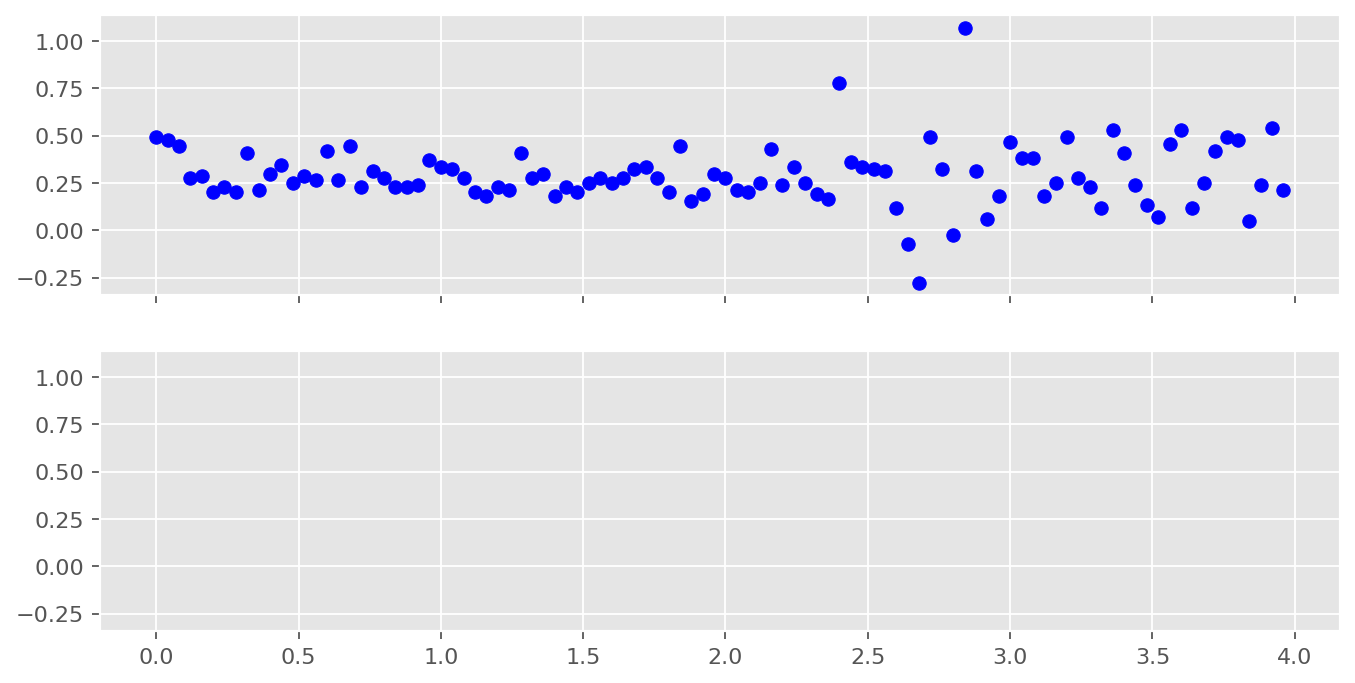

In [ ]:
fig, (ax1, ax2) = plt.subplots(nrows = 2, figsize=(10, 5), dpi = 160, sharex = True, sharey = True)
ax1.scatter(cleaned.reset_index(drop = True).index[:100] / 25.0, cleaned["x"][:100], c = "b")#, alpha = .75)
ax2.scatter(original.reset_index(drop = True).index[:40] / 10.0, original["x"][:40], c = "r")#, alpha = .75)
plt.xlabel("Time (s)")

In [ ]:
cleaned["label"].value_counts(normalize = True)

,proportion
label,
standing,0.187401
grazing,0.134978
Colony,0.123650
climbing_down,0.113325
eating,0.111939
walking,0.094744
Swimming,0.050881
Flying,0.048383
Standing,0.018707


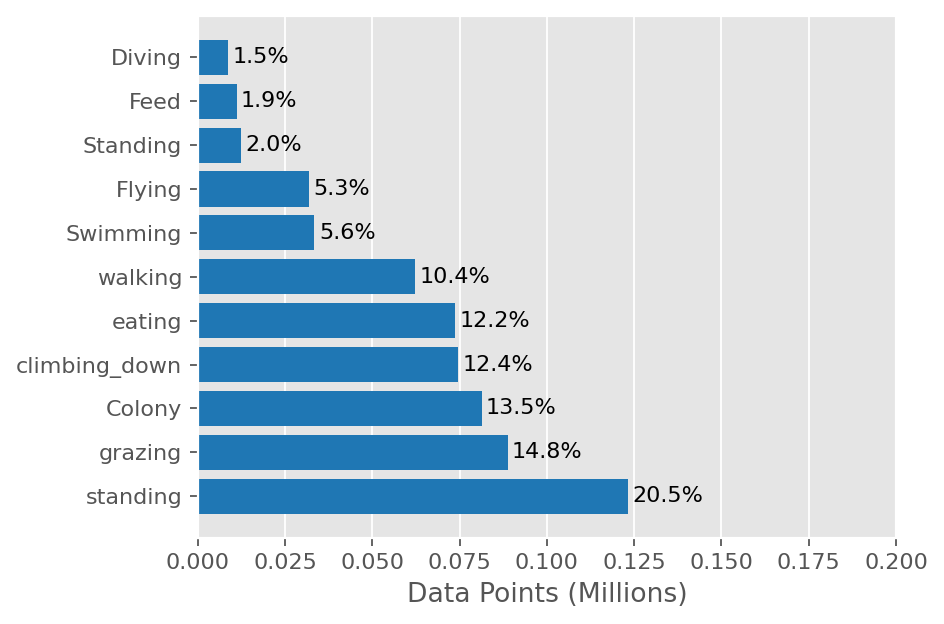

In [ ]:
counts = cleaned["label"].value_counts()[cleaned["label"].value_counts(normalize = True) > .01]

fig, ax = plt.subplots(figsize=(6, 4), dpi = 160)
barplot = plt.barh(y = counts.index, width = counts.array / 1000000, color = "tab:blue")
#fig.suptitle("Data Distribution by Species")
ax.set_xlabel("Data Points (Millions)")
labels = plt.bar_label(barplot, labels=[f'{e:.1f}%' for e in ((counts.array/counts.array.sum())*100) ], padding = 2)
ax.grid(visible = False, axis = "y")
ax.set_xlim([0, .2])
#plt.xticks([2,4,6,8,10])
#ax.grid(visible = True, axis = "x", color = "grey")
#ax.set_axisbelow(True)
plt.tight_layout()

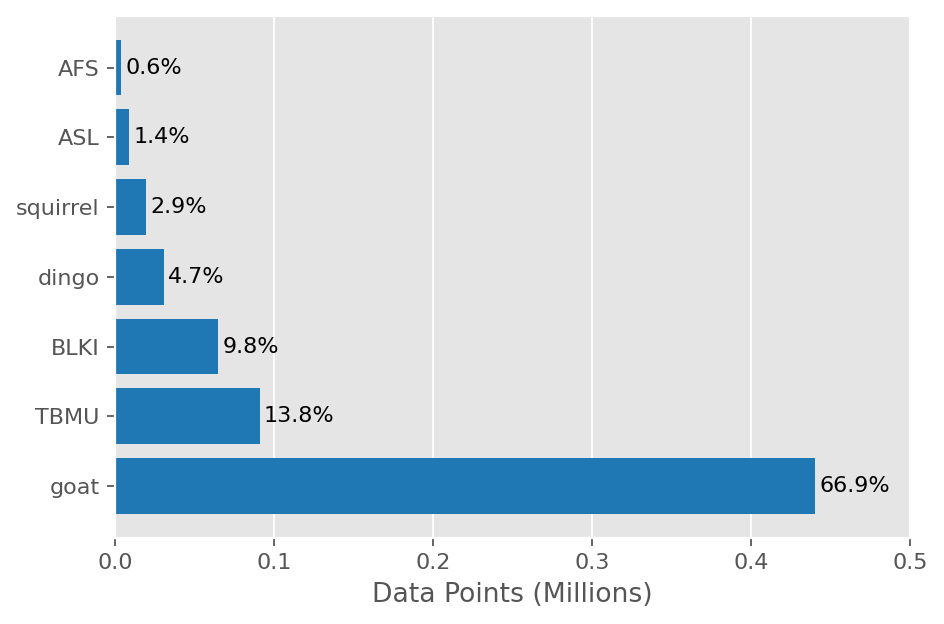

In [ ]:
counts = cleaned["species"].value_counts()[cleaned["species"].value_counts(normalize = True) > .0001]
fig, ax = plt.subplots(figsize=(6, 4), dpi = 160)
barplot = plt.barh(y = counts.index, width = counts.array / 1000000, color = "tab:blue")
#fig.suptitle("Data Distribution by Species")
ax.set_xlabel("Data Points (Millions)")
labels = plt.bar_label(barplot, labels=[f'{e:.1f}%' for e in ((counts.array/counts.array.sum())*100) ], padding = 2)
ax.grid(visible = False, axis = "y")
ax.set_xlim([0, .5])
#plt.xticks([2,4,6,8,10])
#ax.grid(visible = True, axis = "x", color = "grey")
#ax.set_axisbelow(True)
plt.tight_layout()

In [ ]:
temp = cleaned_numeric[cleaned["species"] == "goat"]

pca = decomposition.PCA()
pca.fit(temp)
transformed = pca.transform(temp)

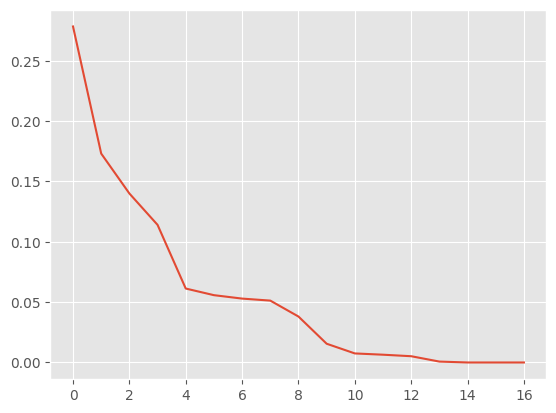

In [ ]:
plt.plot(pca.explained_variance_ratio_)

In [ ]:
cleaned_numeric.corr()

,x,y,z,skew_x,skew_y,skew_z,kurt_x,kurt_y,kurt_z,mean_x,mean_y,mean_z,DBA_x,DBA_y,DBA_z,ODBA,VODBA
x,1.000000,-0.069790,-0.047507,0.012373,-0.005104,-0.002301,0.007284,0.027666,0.014758,0.856521,-0.058008,-0.040155,0.431441,-0.048101,-0.024246,0.044464,0.043336
y,-0.069790,1.000000,-0.622973,0.003744,0.022321,-0.004652,-0.091528,-0.102774,-0.116062,-0.068013,0.960984,-0.663902,-0.015713,0.232817,0.031835,0.669121,0.665777
z,-0.047507,-0.622973,1.000000,0.004672,-0.011927,0.014374,0.065250,0.069943,0.095359,-0.042438,-0.660227,0.927274,-0.017442,0.071403,0.301443,-0.471920,-0.460696
skew_x,0.012373,0.003744,0.004672,1.000000,0.033328,0.020058,0.027426,0.005315,0.000950,-0.009846,0.004386,0.006719,0.041072,-0.001899,-0.004670,0.004724,0.004357
skew_y,-0.005104,0.022321,-0.011927,0.033328,1.000000,0.114474,0.012834,0.047692,-0.007566,-0.004700,0.011323,-0.019974,-0.001629,0.040805,0.019107,0.002776,0.003804
skew_z,-0.002301,-0.004652,0.014374,0.020058,0.114474,1.000000,0.011836,0.008035,0.074925,0.000545,-0.009908,-0.003280,-0.005391,0.018033,0.046632,0.011607,0.010341
kurt_x,0.007284,-0.091528,0.065250,0.027426,0.012834,0.011836,1.000000,0.347633,0.371632,0.006922,-0.094234,0.067772,0.001950,0.000760,0.001162,-0.074983,-0.074151
kurt_y,0.027666,-0.102774,0.069943,0.005315,0.047692,0.008035,0.347633,1.000000,0.360054,0.030793,-0.105552,0.073841,-0.000469,-0.000062,-0.001798,-0.082680,-0.081210
kurt_z,0.014758,-0.116062,0.095359,0.000950,-0.007566,0.074925,0.371632,0.360054,1.000000,0.016714,-0.119676,0.098541,-0.000753,0.001605,0.002978,-0.071341,-0.070135
mean_x,0.856521,-0.068013,-0.042438,-0.009846,-0.004700,0.000545,0.006922,0.030793,0.016714,1.000000,-0.070238,-0.048392,-0.096068,0.001316,0.010232,0.034772,0.034608


In [41]:
temp = (cleaned_numeric.corr().abs() > .5) & (cleaned_numeric.corr().abs() < 1)
for col in temp:
  for item in temp[col].index:
    if temp[col].loc[item] == True:
      print(str(col) + ", " + str(item))

x, mean_x
y, z
y, mean_y
y, mean_z
y, ODBA
y, VODBA
z, y
z, mean_y
z, mean_z
mean_x, x
mean_y, y
mean_y, z
mean_y, mean_z
mean_y, ODBA
mean_y, VODBA
mean_z, y
mean_z, z
mean_z, mean_y
ODBA, y
ODBA, mean_y
ODBA, VODBA
VODBA, y
VODBA, mean_y
VODBA, ODBA


In [57]:
cleaned[cleaned["species"] == "goat"].groupby("label")["ODBA"].mean()

,ODBA
label,
climbing_down,4.239152
climbing_up,11.054592
eating,3.165942
fighting,11.281416
food_fight,6.636716
grazing,3.901472
lying,0.642338
rubbing,4.488339
running,26.763632


In [58]:
pair_counts = cleaned[cleaned["species"] == "goat"]["label"].shift(periods=[0,1]).groupby(['label_0','label_1']).size().reset_index().rename(columns={0:'count'})
pair_counts["prob"] = pair_counts["count"]/pair_counts["count"].sum() * 100

In [61]:
pair_counts

,label_0,label_1,count,prob
0,climbing_down,climbing_down,74510,16.938788
1,climbing_down,climbing_up,1,0.000227
2,climbing_up,climbing_up,771,0.175276
3,climbing_up,food_fight,1,0.000227
4,eating,eating,73599,16.731685
5,eating,running,1,0.000227
6,fighting,eating,1,0.000227
7,fighting,fighting,1507,0.342595
8,food_fight,food_fight,5962,1.355376
9,food_fight,rubbing,1,0.000227


In [62]:
pair_counts[pair_counts["label_0"] != pair_counts["label_1"]]

,label_0,label_1,count,prob
1,climbing_down,climbing_up,1,0.000227
3,climbing_up,food_fight,1,0.000227
5,eating,running,1,0.000227
6,fighting,eating,1,0.000227
9,food_fight,rubbing,1,0.000227
11,grazing,lying,1,0.000227
13,lying,standing,1,0.000227
14,rubbing,fighting,1,0.000227
16,running,grazing,1,0.000227
19,shaking,trotting,1,0.000227


## Results Viewing ##

In [51]:
paths = ['/content/Matrix*.csv'] # Confusion Matrix
F1_obs = []
prec_rec = []
prop = []
all_files = []
for path in paths:
  all_files.extend(glob.glob(path))

for file_name in all_files:
  with open(file_name) as f:
    d = pd.read_csv(f, index_col = 0)
    total_count = d.sum().sum()
    for col in d.columns:
      behavior_prop = d.loc[col].sum() / total_count
      tp = d.loc[col, col]
      fp = d[col].sum() - tp
      fn = d.loc[col].sum() - tp
      f1 = (2*tp) / ((2*tp) + fn + fp)
      if (tp+fn) == 0:
        rec = 0
      else:
        rec = tp/(tp+fn) #Recall
      if (tp+fp) == 0:
        pre = 0
      else:
        pre = tp/(tp+fp) #Precision
      F1_obs.append((behavior_prop, f1))
      prec_rec.append((pre, rec))
      prop.append(behavior_prop)

Text(0, 0.5, 'F1')

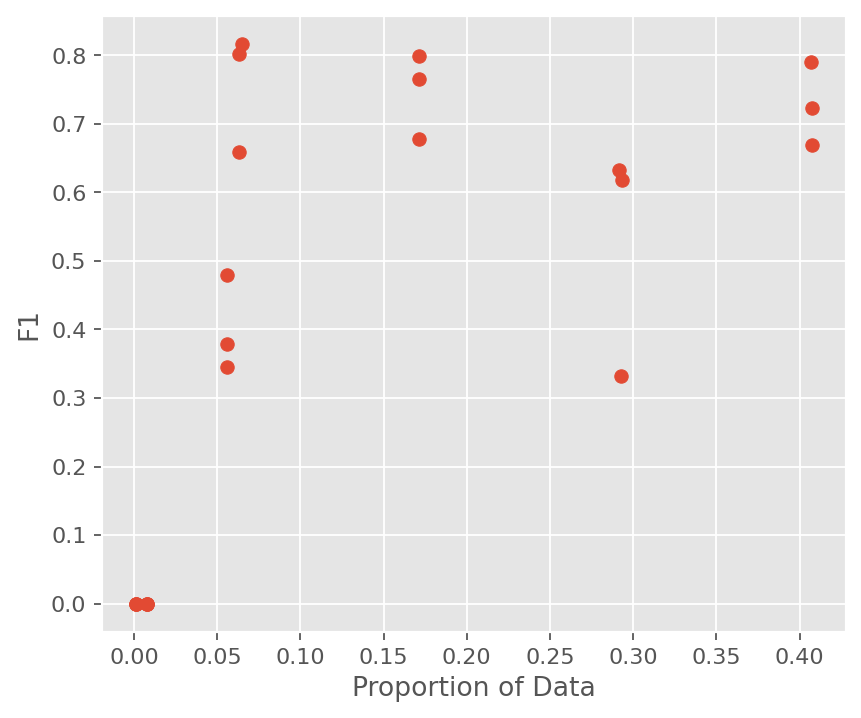

In [52]:
fig, ax = plt.subplots(figsize=(6, 5), dpi = 160)

ax.scatter(*zip(*F1_obs))
ax.set_xlabel("Proportion of Data")
ax.set_ylabel("F1")

Text(0.5, 1.0, 'Proportion')

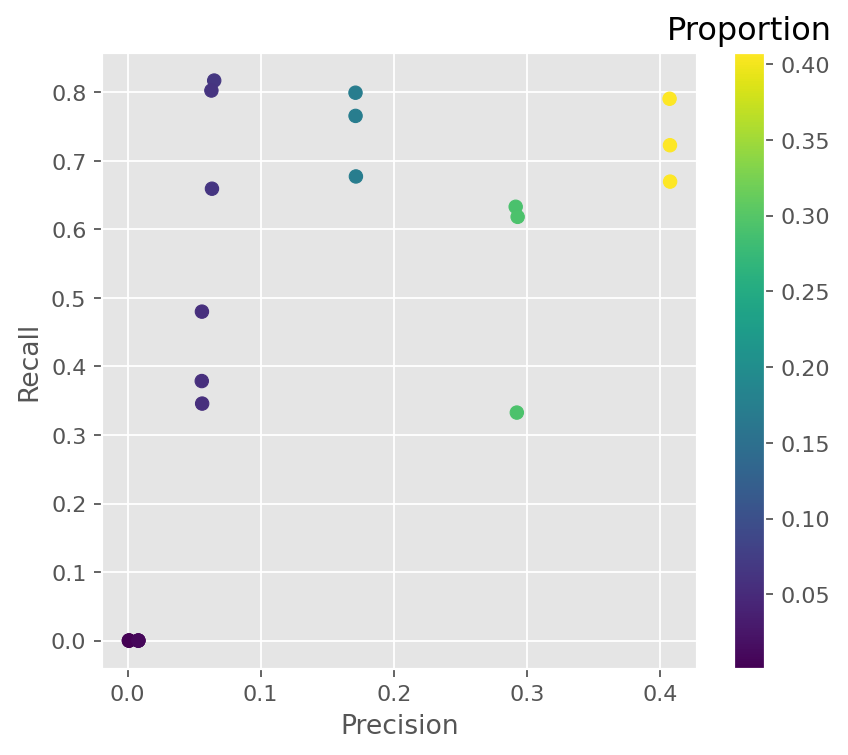

In [53]:
from matplotlib.cm import ScalarMappable
fig, ax = plt.subplots(figsize=(6, 5), dpi = 160)

cmap = plt.get_cmap("viridis")
norm = plt.Normalize(min(prop), max(prop))

ax.scatter(*zip(*F1_obs), c = prop)
ax.set_xlabel("Precision")
ax.set_ylabel("Recall")

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.ax.set_title("Proportion")